In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import kruskal

# Load data
data_ = pd.read_csv(r'Codes\comparison_of_ML_with_1_sensor_position_Multi_202408061550.csv')
df_ = pd.DataFrame(data_)

# Mapping sensor indices and models
mapping_dict = {
    '0_': 'Head_',
    '1_': 'Pelvis_',
    '2_': 'Left Shoulder_',
    '3_': 'Right Shoulder_',
    '4_': 'Left Forearm_',
    '5_': 'Right Forearm_',
    '6_': 'Right Upper Arm_',
    '7_': 'Left Upper Arm_',
    '8_': 'Right Upper Leg_',
    '9_': 'Left Upper Leg_',
    '10_': 'Left Lower Leg_',
    '11_': 'Right Lower Leg_',
}

# Function to replace index values based on the mapping dictionary
def replace_index(index_value):
    for key, value in mapping_dict.items():
        if index_value.startswith(key):
            return index_value.replace(key, value)
    return index_value  # Return original if no match

# Replace indices with sensor names
df_['Sensor'] = df_['index'].apply(lambda x: replace_index(x))
df_['Sensor'] = df_['Sensor'].apply(lambda x: x.split('_')[0])

# Extract the model name from 'index' and create a 'Model' column
df_['Classifier'] = df_['index'].apply(lambda x: x.split('_')[1])
df_['Performance'] = df_['f1_scores']
df_ = df_[['Sensor', 'Classifier', 'Performance']]
df = pd.DataFrame(df_)

# df.head(50)
# Analyze each sensor separately
results = []

for sensor in df['Sensor'].unique():
    sensor_data = df[df['Sensor'] == sensor]
    
    # Perform Kruskal-Wallis test
    groups = [sensor_data[sensor_data['Classifier'] == classifier]['Performance'] for classifier in sensor_data['Classifier'].unique()]
    kruskal_stat, p_value = kruskal(*groups)
    
    # Perform Tukey's HSD post-hoc test if Kruskal-Wallis is significant
    if p_value < 0.05:
        tukey = pairwise_tukeyhsd(sensor_data['Performance'], sensor_data['Classifier'])
        tukey_summary = tukey.summary()
        print(f"\n{sensor} - Tukey's HSD results:\n{tukey_summary}")
    
    # Calculate mean and standard deviation
    means = sensor_data.groupby('Classifier')['Performance'].mean()
    stds = sensor_data.groupby('Classifier')['Performance'].std()
    
    best_classifier = means.idxmax()
    best_mean = means.max()
    
    results.append({
        'Sensor': sensor,
        'Best_Classifier': best_classifier,
        'Best_Mean_Performance': best_mean,
        'Kruskal_p_value': p_value
    })

# Create a summary DataFrame
summary_df = pd.DataFrame(results)
print(summary_df)
print(summary_df.T.to_excel("The_most_effective_model_across_12_sensors.xlsx"))

# Plotting
plt.figure(figsize=(14, 8))

# for sensor in df['Sensor'].unique():
#     sensor_data = df[df['Sensor'] == sensor]
#     sns.barplot(x='Classifier', y='Performance', data=sensor_data, capsize=0.2, errorbar='sd')
#     plt.title(f'{sensor} Performance Comparison')
#     plt.ylabel('Performance')
#     plt.xlabel('Classifier')
#     plt.show()



Head - Tukey's HSD results:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   KNN    MLP   0.0696    0.0  0.0334  0.1058   True
   KNN     RF   0.0041 0.9896  -0.032  0.0403  False
   KNN    SVM   0.0923    0.0  0.0561  0.1284   True
   MLP     RF  -0.0654 0.0001 -0.1016 -0.0293   True
   MLP    SVM   0.0227 0.3445 -0.0135  0.0588  False
    RF    SVM   0.0881    0.0  0.0519  0.1243   True
----------------------------------------------------

Pelvis - Tukey's HSD results:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   KNN    MLP   0.0607    0.0  0.0332  0.0882   True
   KNN     RF   0.0275 0.0491  0.0001   0.055   True
   KNN    SVM   0.0798    0.0  0.0523  0.1072   True
   MLP     RF  -0.0332 0.0127 -0.0606 -0.0057   True
   MLP    SVM   0.0191  0.258 -0.0084  

<Figure size 1400x800 with 0 Axes>

<Figure size 1400x800 with 0 Axes>

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Load data
data_ = pd.read_csv(r'Codes\comparison_of_ML_with_1_sensor_position_Multi_202408061550.csv')
df_ = pd.DataFrame(data_)

# Mapping sensor indices and models
mapping_dict = {
    '0_': 'Head_',
    '1_': 'Pelvis_',
    '2_': 'Left Shoulder_',
    '3_': 'Right Shoulder_',
    '4_': 'Left Forearm_',
    '5_': 'Right Forearm_',
    '6_': 'Right Upper Arm_',
    '7_': 'Left Upper Arm_',
    '8_': 'Right Upper Leg_',
    '9_': 'Left Upper Leg_',
    '10_': 'Left Lower Leg_',
    '11_': 'Right Lower Leg_',
}

# Function to replace index values based on the mapping dictionary
def replace_index(index_value):
    for key, value in mapping_dict.items():
        if index_value.startswith(key):
            return index_value.replace(key, value)
    return index_value  # Return original if no match

# Replace indices with sensor names
df_['Sensor'] = df_['index'].apply(lambda x: replace_index(x))
df_['Sensor'] = df_['Sensor'].apply(lambda x: x.split('_')[0])

# Extract the model name from 'index' and create a 'Model' column
df_['Classifier'] = df_['index'].apply(lambda x: x.split('_')[1])
df_['Performance'] = df_['f1_scores']
df_ = df_[['Sensor', 'Classifier', 'Performance']]
df = pd.DataFrame(df_)

# Analyze each sensor separately
results = []

for sensor in df['Sensor'].unique():
    sensor_data = df[df['Sensor'] == sensor]
    
    # Perform Kruskal-Wallis test
    groups = [sensor_data[sensor_data['Classifier'] == classifier]['Performance'] for classifier in sensor_data['Classifier'].unique()]
    kruskal_stat, p_value = kruskal(*groups)
    
    # Perform Tukey's HSD post-hoc test if Kruskal-Wallis is significant
    if p_value < 0.05:
        tukey = pairwise_tukeyhsd(sensor_data['Performance'], sensor_data['Classifier'])
        tukey_summary = tukey.summary()
        print(f"\n{sensor} - Tukey's HSD results:\n{tukey_summary}")
    
    # Calculate mean and standard deviation
    means = sensor_data.groupby('Classifier')['Performance'].mean().sort_values(ascending=False)
    stds = sensor_data.groupby('Classifier')['Performance'].std()
    
    # Capture the best, second-best, third-best, and lowest classifier
    best_classifier = means.index[0]
    second_best_classifier = means.index[1]
    third_best_classifier = means.index[2]
    lowest_classifier = means.index[-1]
    
    best_mean = means.iloc[0]
    second_best_mean = means.iloc[1]
    third_best_mean = means.iloc[2]
    lowest_mean = means.iloc[-1]
    
    results.append({
        'Sensor': sensor,
        'Best_Classifier': best_classifier,
        'Best_Mean_Performance': best_mean,
        'Second_Best_Classifier': second_best_classifier,
        'Second_Best_Mean_Performance': second_best_mean,
        'Third_Best_Classifier': third_best_classifier,
        'Third_Best_Mean_Performance': third_best_mean,
        'Lowest_Classifier': lowest_classifier,
        'Lowest_Mean_Performance': lowest_mean,
        'Kruskal_p_value': p_value
    })

# Create a summary DataFrame
summary_df = pd.DataFrame(results)
print(summary_df)

# Exporting the summary
summary_df.T.to_excel("The_most_effective_model_across_12_sensors_with_ranking 1.xlsx")

# # Plotting
# plt.figure(figsize=(14, 8))

# for sensor in df['Sensor'].unique():
#     sensor_data = df[df['Sensor'] == sensor]
#     sns.barplot(x='Classifier', y='Performance', data=sensor_data, capsize=0.2, errorbar='sd')
#     plt.title(f'{sensor} Performance Comparison')
#     plt.ylabel('Performance')
#     plt.xlabel('Classifier')
#     plt.show()



Head - Tukey's HSD results:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   KNN    MLP   0.0696    0.0  0.0334  0.1058   True
   KNN     RF   0.0041 0.9896  -0.032  0.0403  False
   KNN    SVM   0.0923    0.0  0.0561  0.1284   True
   MLP     RF  -0.0654 0.0001 -0.1016 -0.0293   True
   MLP    SVM   0.0227 0.3445 -0.0135  0.0588  False
    RF    SVM   0.0881    0.0  0.0519  0.1243   True
----------------------------------------------------

Pelvis - Tukey's HSD results:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   KNN    MLP   0.0607    0.0  0.0332  0.0882   True
   KNN     RF   0.0275 0.0491  0.0001   0.055   True
   KNN    SVM   0.0798    0.0  0.0523  0.1072   True
   MLP     RF  -0.0332 0.0127 -0.0606 -0.0057   True
   MLP    SVM   0.0191  0.258 -0.0084  

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Codes\comparison_of_ML_with_1_sensor_position_Multi_202408061550.csv
# Load data
file_path = 'Codes/comparison_of_ML_with_1_sensor_position_Multi_202408061550.csv'
data_ = pd.read_csv(file_path)
df_ = pd.DataFrame(data_)

# Mapping sensor indices and models
mapping_dict = {
    '0_': 'Head_',
    '1_': 'Pelvis_',
    '2_': 'Left Shoulder_',
    '3_': 'Right Shoulder_',
    '4_': 'Left Forearm_',
    '5_': 'Right Forearm_',
    '6_': 'Right Upper Arm_',
    '7_': 'Left Upper Arm_',
    '8_': 'Right Upper Leg_',
    '9_': 'Left Upper Leg_',
    '10_': 'Left Lower Leg_',
    '11_': 'Right Lower Leg_',
}

# Function to replace index values based on the mapping dictionary
def replace_index(index_value):
    for key, value in mapping_dict.items():
        if index_value.startswith(key):
            return index_value.replace(key, value)
    return index_value  # Return original if no match

# Replace indices with sensor names
df_['Sensor'] = df_['index'].apply(lambda x: replace_index(x))
df_['Sensor'] = df_['Sensor'].apply(lambda x: x.split('_')[0])

# Extract the model name from 'index' and create a 'Classifier' column
df_['Classifier'] = df_['index'].apply(lambda x: x.split('_')[1])
df_['Performance'] = df_['f1_scores']
df_ = df_[['Sensor', 'Classifier', 'Performance']]
df = pd.DataFrame(df_)

# Analyze each sensor separately and rank the classifiers
results = []

for sensor in df['Sensor'].unique():
    sensor_data = df[df['Sensor'] == sensor]
    
    # Perform Kruskal-Wallis test
    groups = [sensor_data[sensor_data['Classifier'] == classifier]['Performance'] for classifier in sensor_data['Classifier'].unique()]
    kruskal_stat, p_value = kruskal(*groups)
    
    # Perform Tukey's HSD post-hoc test if Kruskal-Wallis is significant
    if p_value < 0.05:
        tukey = pairwise_tukeyhsd(sensor_data['Performance'], sensor_data['Classifier'])
        tukey_summary = tukey.summary()
    
    # Calculate mean performance
    means = sensor_data.groupby('Classifier')['Performance'].mean().sort_values(ascending=False)
    
    # Capture the top 4 classifiers and their mean performances
    results.append({
        'Sensor': sensor,
        'SVM': means.get('SVM', np.nan),
        'MLP': means.get('MLP', np.nan),
        'RF': means.get('RF', np.nan),
        'KNN': means.get('KNN', np.nan),
        'p_value': p_value
    })

# Create a summary DataFrame
summary_df = pd.DataFrame(results)

# Define status based on p-value threshold
summary_df['status'] = summary_df['p_value'] < 0.05

# Save the overall ranking to CSV
summary_df.to_csv("Sensor_Classifier_Performance_with_Statistics.csv", index=False)

# Compare ranking 1 and 2 (SVM and MLP) for each sensor
comparison_1_2_results = []
comparison_1_3_results = []
comparison_1_4_results = []
comparison_3_4_results = []

for sensor in df['Sensor'].unique():
    sensor_data = df[df['Sensor'] == sensor]
    
    # Filter data for SVM and MLP (ranking 1 and 2)
    top_2_data = sensor_data[sensor_data['Classifier'].isin(['SVM', 'MLP'])]
    
    # Perform Kruskal-Wallis test between SVM and MLP
    groups = [top_2_data[top_2_data['Classifier'] == classifier]['Performance'] for classifier in ['SVM', 'MLP']]
    kruskal_stat, p_value2 = kruskal(*groups)
    
    # Add comparison results to list
    comparison_1_2_results.append({
        'Sensor': sensor,
        'SVM': top_2_data[top_2_data['Classifier'] == 'SVM']['Performance'].mean(),
        'MLP': top_2_data[top_2_data['Classifier'] == 'MLP']['Performance'].mean(),
        'p_value': p_value2,
        'status': p_value2 < 0.05
    })

    # Filter data for RF and KNN (ranking 3 and 4)
    bottom_2_data = sensor_data[sensor_data['Classifier'].isin(['RF', 'KNN'])]
    
    # Perform Kruskal-Wallis test between RF and KNN
    groups = [bottom_2_data[bottom_2_data['Classifier'] == classifier]['Performance'] for classifier in ['RF', 'KNN']]
    kruskal_stat, p_value3 = kruskal(*groups)
    
    # Add comparison results to list
    comparison_3_4_results.append({
        'Sensor': sensor,
        'RF': bottom_2_data[bottom_2_data['Classifier'] == 'RF']['Performance'].mean(),
        'KNN': bottom_2_data[bottom_2_data['Classifier'] == 'KNN']['Performance'].mean(),
        'p_value': p_value3,
        'status': p_value3 < 0.05
    })

    # Filter data for SVM and RF (ranking 1 and 3)
    top_3_data = sensor_data[sensor_data['Classifier'].isin(['SVM', 'RF'])]
    
    # Perform Kruskal-Wallis test between SVM and RF
    groups = [top_3_data[top_3_data['Classifier'] == classifier]['Performance'] for classifier in ['SVM', 'RF']]
    kruskal_stat, p_value4 = kruskal(*groups)
    
    # Add comparison results to list
    comparison_1_3_results.append({
        'Sensor': sensor,
        'SVM': top_3_data[top_3_data['Classifier'] == 'SVM']['Performance'].mean(),
        'RF': top_3_data[top_3_data['Classifier'] == 'RF']['Performance'].mean(),
        'p_value': p_value4,
        'status': p_value4 < 0.05
    })

    # Filter data for SVM and RF (ranking 1 and 3)
    top_1_4_data = sensor_data[sensor_data['Classifier'].isin(['SVM', 'KNN'])]
    
    # Perform Kruskal-Wallis test between SVM and RF
    groups = [top_1_4_data[top_1_4_data['Classifier'] == classifier]['Performance'] for classifier in ['SVM', 'KNN']]
    kruskal_stat, p_value = kruskal(*groups)
    
    # Add comparison results to list
    comparison_1_4_results.append({
        'Sensor': sensor,
        'SVM': top_1_4_data[top_1_4_data['Classifier'] == 'SVM']['Performance'].mean(),
        'KNN': top_1_4_data[top_1_4_data['Classifier'] == 'KNN']['Performance'].mean(),
        'p_value': p_value,
        'status': p_value < 0.05
    })


# Convert the comparison results into DataFrames
comparison_1_2_df = pd.DataFrame(comparison_1_2_results)
comparison_1_3_df = pd.DataFrame(comparison_1_3_results)
comparison_1_4_df = pd.DataFrame(comparison_1_4_results)
comparison_3_4_df = pd.DataFrame(comparison_3_4_results)

# Save the comparison results to CSV
comparison_1_2_df.T.to_csv("Sensor_Top_2_Classifier_Comparison.csv", index=False)
comparison_3_4_df.T.to_csv("Sensor_Bottom_2_Classifier_Comparison.csv", index=False)
# Save the comparison results to CSV
comparison_1_3_df.T.to_csv("Sensor_Top_1_vs_3_Classifier_Comparison.csv", index=False)
comparison_1_4_df.T.to_csv("Sensor_Top_1_vs_4_Classifier_Comparison.csv", index=False)


# Display the results (Optional: Print them out)
print("Top 1 vs 2 Classifier Comparison (SVM and MLP):")
print(comparison_1_2_df)
print("\nTop 1 vs 3 Classifier Comparison (SVM and RF):")
print(comparison_1_3_df)
print("\nTop 1 vs 4 Classifier Comparison (SVM and KNN):")
print(comparison_1_4_df)
print("\n3 vs 4 Classifier Comparison (RF and KNN):")
print(comparison_3_4_df)


Top 1 vs 2 Classifier Comparison (SVM and MLP):
             Sensor       SVM       MLP   p_value  status
0              Head  0.757431  0.734761  0.112411   False
1            Pelvis  0.872415  0.853333  0.082099   False
2     Left Shoulder  0.765259  0.750439  0.364346   False
3    Right Shoulder  0.773983  0.739113  0.023342    True
4      Left Forearm  0.561450  0.550905  0.364346   False
5     Right Forearm  0.571622  0.549210  0.325751   False
6   Right Upper Arm  0.663689  0.652265  0.405679   False
7    Left Upper Arm  0.634929  0.610955  0.130570   False
8   Right Upper Leg  0.856895  0.837644  0.096304   False
9    Left Upper Leg  0.842976  0.827019  0.049366    True
10   Left Lower Leg  0.790089  0.765738  0.082099   False
11  Right Lower Leg  0.802057  0.787501  0.198765   False

Top 1 vs 3 Classifier Comparison (SVM and RF):
             Sensor       SVM        RF   p_value  status
0              Head  0.757431  0.669323  0.000381    True
1            Pelvis  0.872415  0.8

In [4]:
import pandas as pd
import numpy as np
from scipy.stats import kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Load data
file_path = 'Codes/comparison_of_ML_with_1_sensor_position_Multi_202408061550.csv'
data_ = pd.read_csv(file_path)
df_ = pd.DataFrame(data_)

# Mapping sensor indices and models
mapping_dict = {
    '0_': 'Head_',
    '1_': 'Pelvis_',
    '2_': 'Left Shoulder_',
    '3_': 'Right Shoulder_',
    '4_': 'Left Forearm_',
    '5_': 'Right Forearm_',
    '6_': 'Right Upper Arm_',
    '7_': 'Left Upper Arm_',
    '8_': 'Right Upper Leg_',
    '9_': 'Left Upper Leg_',
    '10_': 'Left Lower Leg_',
    '11_': 'Right Lower Leg_',
}

# Function to replace index values based on the mapping dictionary
def replace_index(index_value):
    for key, value in mapping_dict.items():
        if index_value.startswith(key):
            return index_value.replace(key, value)
    return index_value  # Return original if no match

# Replace indices with sensor names
df_['Sensor'] = df_['index'].apply(lambda x: replace_index(x))
df_['Sensor'] = df_['Sensor'].apply(lambda x: x.split('_')[0])

# Extract the model name from 'index' and create a 'Classifier' column
df_['Classifier'] = df_['index'].apply(lambda x: x.split('_')[1])
df_['Performance'] = df_['f1_scores']
df_ = df_[['Sensor', 'Classifier', 'Performance']]
df = pd.DataFrame(df_)

# Compare rankings 1 and 3 (SVM and RF)

comparison_1_3_results = []

for sensor in df['Sensor'].unique():
    sensor_data = df[df['Sensor'] == sensor]
    
    # Filter data for SVM and RF (ranking 1 and 3)
    top_3_data = sensor_data[sensor_data['Classifier'].isin(['SVM', 'RF'])]
    
    # Perform Kruskal-Wallis test between SVM and RF
    groups = [top_3_data[top_3_data['Classifier'] == classifier]['Performance'] for classifier in ['SVM', 'RF']]
    kruskal_stat, p_value = kruskal(*groups)
    
    # Add comparison results to list
    comparison_1_3_results.append({
        'Sensor': sensor,
        'SVM': top_3_data[top_3_data['Classifier'] == 'SVM']['Performance'].mean(),
        'RF': top_3_data[top_3_data['Classifier'] == 'RF']['Performance'].mean(),
        'p_value': p_value,
        'status': p_value < 0.05
    })

# Convert the comparison results into a DataFrame
comparison_1_3_df = pd.DataFrame(comparison_1_3_results)

# Save the comparison results to CSV
comparison_1_3_df.T.to_csv("Sensor_Top_1_vs_3_Classifier_Comparison.csv", index=False)

# Display the results
print("Sensor Top 1 vs 3 Classifier Comparison (SVM and RF):")
print(comparison_1_3_df)


Sensor Top 1 vs 3 Classifier Comparison (SVM and RF):
             Sensor       SVM        RF   p_value  status
0              Head  0.757431  0.669323  0.000381    True
1            Pelvis  0.872415  0.820165  0.000212    True
2     Left Shoulder  0.765259  0.708464  0.000881    True
3    Right Shoulder  0.773983  0.696601  0.000881    True
4      Left Forearm  0.561450  0.516768  0.015564    True
5     Right Forearm  0.571622  0.526291  0.003197    True
6   Right Upper Arm  0.663689  0.591305  0.001152    True
7    Left Upper Arm  0.634929  0.587798  0.023342    True
8   Right Upper Leg  0.856895  0.786854  0.000507    True
9    Left Upper Leg  0.842976  0.785455  0.000212    True
10   Left Lower Leg  0.790089  0.745024  0.001499    True
11  Right Lower Leg  0.802057  0.759284  0.001499    True


Mean F1 Scores:
Model
KNN    0.655272
MLP    0.721574
RF     0.682778
SVM    0.741066
Name: f1_scores, dtype: float64

Mann-Whitney U Test p-values:
           RF       SVM       MLP       KNN
RF        NaN   0.00001  0.003393  0.046728
SVM   0.00001       NaN  0.099257       0.0
MLP  0.003393  0.099257       NaN  0.000003
KNN  0.046728       0.0  0.000003       NaN

Dunn's Multiple Comparison Test Results:
              KNN       MLP        RF           SVM
KNN  1.000000e+00  0.000004  0.072892  9.142028e-10
MLP  3.878354e-06  1.000000  0.004739  1.320891e-01
RF   7.289158e-02  0.004739  1.000000  1.489722e-05
SVM  9.142028e-10  0.132089  0.000015  1.000000e+00


C:\Users\sokea\AppData\Local\Temp\ipykernel_18632\3321937212.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_f1_scores.index, y=mean_f1_scores.values, palette='viridis')


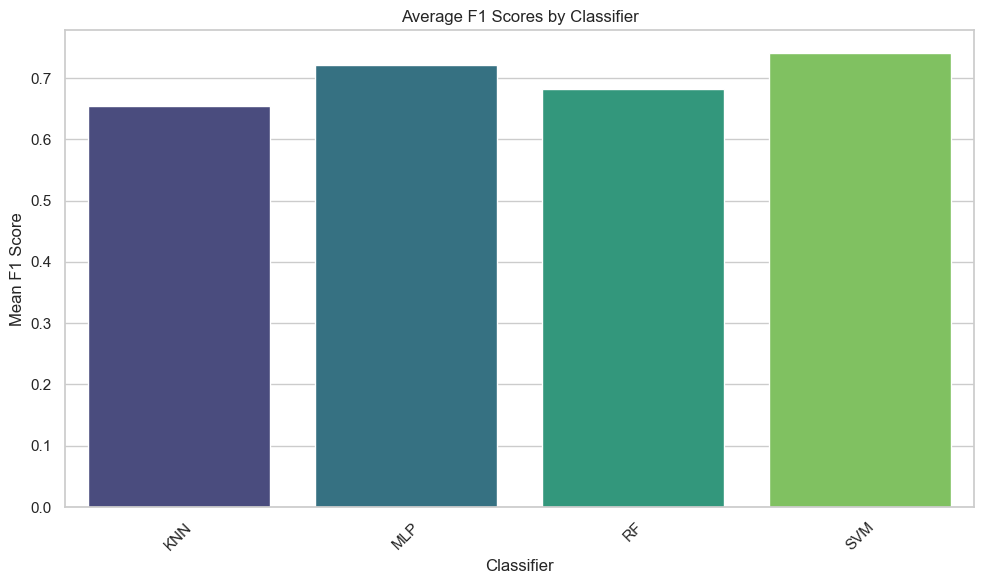

In [21]:
import numpy as np
import pandas as pd
import scipy.stats as stats
from scikit_posthocs import posthoc_dunn
import matplotlib.pyplot as plt

# Load the data
data_path = r'Codes\comparison_of_ML_with_1_sensor_position_Multi_202408061550.csv'
df = pd.read_csv(data_path)

# Mapping sensor indices and models
mapping_dict = {
    '0_': 'Head',
    '1_': 'Pelvis',
    '2_': 'Left Shoulder',
    '3_': 'Right Shoulder',
    '4_': 'Left Forearm',
    '5_': 'Right Forearm',
    '6_': 'Right Upper Arm',
    '7_': 'Left Upper Arm',
    '8_': 'Right Upper Leg',
    '9_': 'Left Upper Leg',
    '10_': 'Left Lower Leg',
    '11_': 'Right Lower Leg',
}

# Replace indices with sensor names and extract the model
df['Sensor'] = df['index'].apply(lambda x: next((value for key, value in mapping_dict.items() if x.startswith(key)), x))
df['Model'] = df['index'].apply(lambda x: x.split('_')[1])

# Calculate the mean F1 scores for each classifier across all sensors
mean_f1_scores = df.groupby('Model')['f1_scores'].mean()

# Prepare data for Mann-Whitney U test
models = df['Model'].unique()
p_values_mann_whitney = pd.DataFrame(index=models, columns=models)

# Perform Mann-Whitney U test for all pairs
for model1 in models:
    for model2 in models:
        if model1 != model2:
            scores1 = df[df['Model'] == model1]['f1_scores']
            scores2 = df[df['Model'] == model2]['f1_scores']
            u_stat, p_value = stats.mannwhitneyu(scores1, scores2)
            p_values_mann_whitney.loc[model1, model2] = p_value

# Perform Dunn's multiple comparison test
dunn_results = posthoc_dunn(df, val_col='f1_scores', group_col='Model')

# Output results
print("Mean F1 Scores:")
print(mean_f1_scores)

print("\nMann-Whitney U Test p-values:")
print(p_values_mann_whitney)

print("\nDunn's Multiple Comparison Test Results:")
print(dunn_results)

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x=mean_f1_scores.index, y=mean_f1_scores.values, palette='viridis')
plt.title('Average F1 Scores by Classifier')
plt.xlabel('Classifier')
plt.ylabel('Mean F1 Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



ANOVA results:
              sum_sq     df           F         PR(>F)
C(placess)  5.026433   11.0  676.765693  3.019272e-279
Residual    0.315991  468.0         NaN            NaN

Pairwise Comparisons (LSD Test) for Accuracy (Table Format):
|    | A       | B       | C       | D       | E      | F      | H       | G       | J       | I       | K       | L       |
|:---|:--------|:--------|:--------|:--------|:-------|:-------|:--------|:--------|:--------|:--------|:--------|:--------|
| A  | -       | -0.11 * | -0.01   | -0.02 * | 0.20 * | 0.19 * | 0.09 *  | 0.12 *  | -0.10 * | -0.09 * | -0.03 * | -0.04 * |
| B  | 0.11 *  | -       | 0.11 *  | 0.10 *  | 0.31 * | 0.30 * | 0.21 *  | 0.24 *  | 0.02 *  | 0.03 *  | 0.08 *  | 0.07 *  |
| C  | 0.01    | -0.11 * | -       | -0.01   | 0.20 * | 0.19 * | 0.10 *  | 0.13 *  | -0.09 * | -0.08 * | -0.02 * | -0.04 * |
| D  | 0.02 *  | -0.10 * | 0.01    | -       | 0.21 * | 0.20 * | 0.11 *  | 0.14 *  | -0.08 * | -0.07 * | -0.02 * | -0.03 * |
| E  | 

C:\Users\sokea\AppData\Local\Temp\ipykernel_8188\277519022.py:37: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if anova_table['PR(>F)'][0] < 0.05:
C:\Users\sokea\AppData\Local\Temp\ipykernel_8188\277519022.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mse = anova_table['sum_sq'][1] / anova_table['df'][1]
C:\Users\sokea\AppData\Local\Temp\ipykernel_8188\277519022.py:45: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_error =

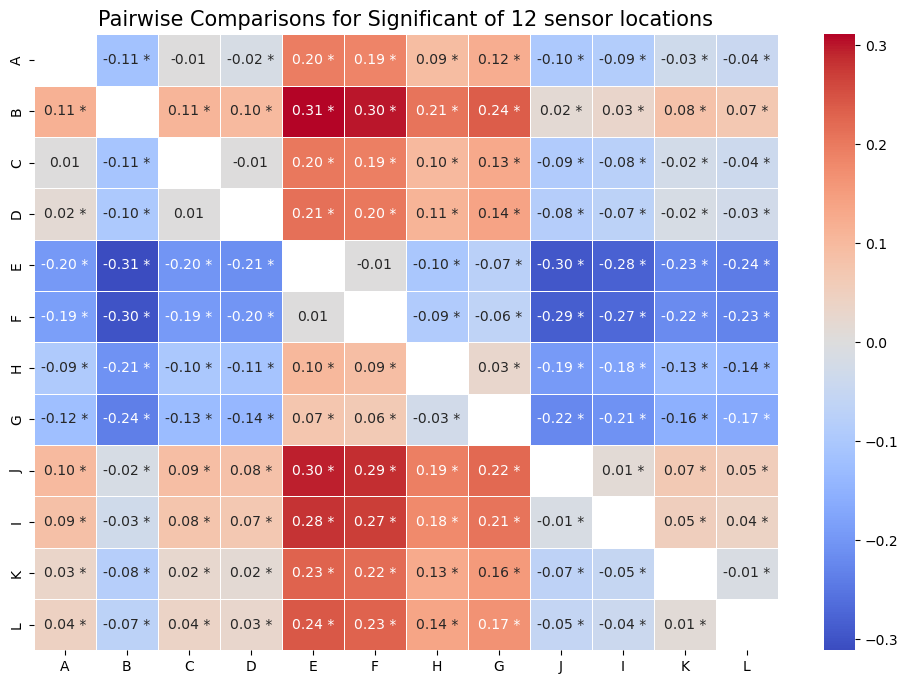

In [2]:
import pandas as pd
import numpy as np
from scipy.stats import t
from itertools import combinations
import statsmodels.api as sm
from statsmodels.formula.api import ols
import ast
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
data_ = pd.read_csv(r'Codes\comparison of all Lower_Upper_SVM sensor position_Multi_.csv')
df_ = pd.DataFrame(data_)

# Process data
df_['placess'] = df_['placess'].apply(ast.literal_eval)
df_['placess'] = df_['placess'].apply(lambda x: ''.join(x))
df_['Num_Sensors'] = df_['placess'].apply(len)
df_['Performance'] = df_['f1_scores']
# df_['Performance'] = np.sqrt(df_['specificities'] * df_['recalls'])

# Filter data for single sensor
data = df_[df_['Num_Sensors'] == 1]
df = pd.DataFrame(data)

# Melt the dataframe for ANOVA
df_melted = pd.melt(df, id_vars=['placess'], value_vars=['accuracies', 'precisions', 'recalls', 'f1_scores'])
df_melted.columns = ['placess', 'Metric', 'Value']

# Perform ANOVA
model = ols('Value ~ C(placess)', data=df_melted).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print("\nANOVA results:")
print(anova_table)

# If ANOVA is significant, perform LSD test
if anova_table['PR(>F)'][0] < 0.05:
    # Mean Square Error
    mse = anova_table['sum_sq'][1] / anova_table['df'][1]

    # Number of replicates for each group
    num_replicates = df_melted.groupby('placess').size().mean()

    # Degrees of freedom for error
    df_error = anova_table['df'][1]

    # Calculate LSD
    def calculate_lsd(mse, df_error, num_replicates, alpha=0.05):
        t_value = t.ppf(1 - alpha / 2, df_error)
        return t_value * np.sqrt(2 * mse / num_replicates)

    lsd = calculate_lsd(mse, df_error, num_replicates)

    # Pairwise comparisons
    comparisons = []
    experiments = df['placess'].unique()
    for exp1, exp2 in combinations(experiments, 2):
        mean1 = df[df['placess'] == exp1]['Performance'].mean()
        mean2 = df[df['placess'] == exp2]['Performance'].mean()
        mean_diff = mean1 - mean2
        significant = abs(mean_diff) > lsd
        comparisons.append((exp1, exp2, mean_diff, significant))

    # Create a numerical comparison matrix and an annotation matrix
    comparison_matrix = pd.DataFrame(index=experiments, columns=experiments, dtype=float)
    annotation_matrix = pd.DataFrame(index=experiments, columns=experiments, dtype=object)
    for exp1, exp2, mean_diff, significant in comparisons:
        value = mean_diff if significant else 0  # Use 0 for non-significant values
        comparison_matrix.loc[exp1, exp2] = value
        comparison_matrix.loc[exp2, exp1] = -value
        annotation = f"{mean_diff:.2f}{' *' if significant else ''}"
        annotation_matrix.loc[exp1, exp2] = annotation
        annotation_matrix.loc[exp2, exp1] = f"{-mean_diff:.2f}{' *' if significant else ''}"

    # Fill diagonal with dashes
    np.fill_diagonal(annotation_matrix.values, '-')

    # Print the comparison matrix
    print("\nPairwise Comparisons (LSD Test) for Accuracy (Table Format):")
    print(annotation_matrix.to_markdown())

    # Create mask for the heatmap
    mask = np.zeros_like(comparison_matrix, dtype=bool)
    np.fill_diagonal(mask, True)

    # Plot the comparison matrix
    plt.figure(figsize=(12, 8))
    sns.heatmap(comparison_matrix, annot=annotation_matrix, fmt='', cmap='coolwarm', cbar=True, mask=mask,
                linewidths=.5, annot_kws={"size": 10}, center=0)
    plt.title("Pairwise Comparisons for Significant of 12 sensor locations", fontsize=15)
    plt.show()

else:
    print("ANOVA did not show significant differences. LSD test not performed.")


T-statistic: -1.0864
P-value: 0.2917


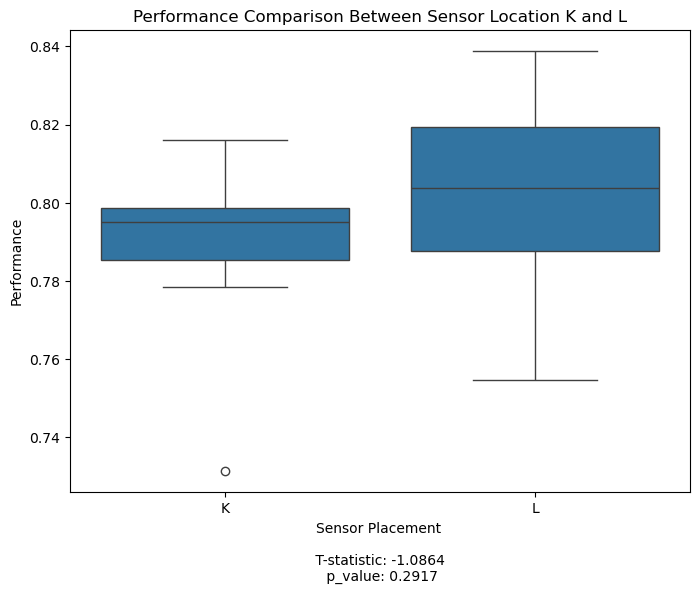

In [7]:
import pandas as pd
import numpy as np
from scipy.stats import t
from itertools import combinations
import statsmodels.api as sm
from statsmodels.formula.api import ols
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load data
data_ = pd.read_csv(r'Codes\comparison of all Lower_Upper_SVM sensor position_Multi_.csv')
df_ = pd.DataFrame(data_)

# Process data
df_['placess'] = df_['placess'].apply(ast.literal_eval)
df_['placess'] = df_['placess'].apply(lambda x: ''.join(x))
df_['Num_Sensors'] = df_['placess'].apply(len)
df_['Performance'] = df_['f1_scores']
# df_['Performance'] = np.sqrt(df_['specificities'] * df_['recalls'])

# Filter data for single sensor
# data = df_[df_['Num_Sensors'] == 1]
df = df_[df_['placess'].isin(['K', 'L'])]
df1 = df_[df_['placess'].isin(['K'])]
df1 = df1['f1_scores']
df2 = df_[df_['placess'].isin(['L'])]
df2 = df2['f1_scores']

# Perform t-test
t_stat, p_value = stats.ttest_ind(df1, df2, equal_var=True)  # Use equal_var=False if variances are not equal

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")
# Create a boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x='placess', y='f1_scores', data=df)
plt.title(f'Performance Comparison Between Sensor Location K and L')
plt.xlabel(f'Sensor Placement \n\n T-statistic: {t_stat:.4f} \n p_value: {p_value:.4f}')
plt.ylabel('Performance')
plt.show()

              sum_sq     df          F        PR(>F)
C(placess)  0.876008   14.0  77.477037  2.657756e-57
Residual    0.109029  135.0        NaN           NaN


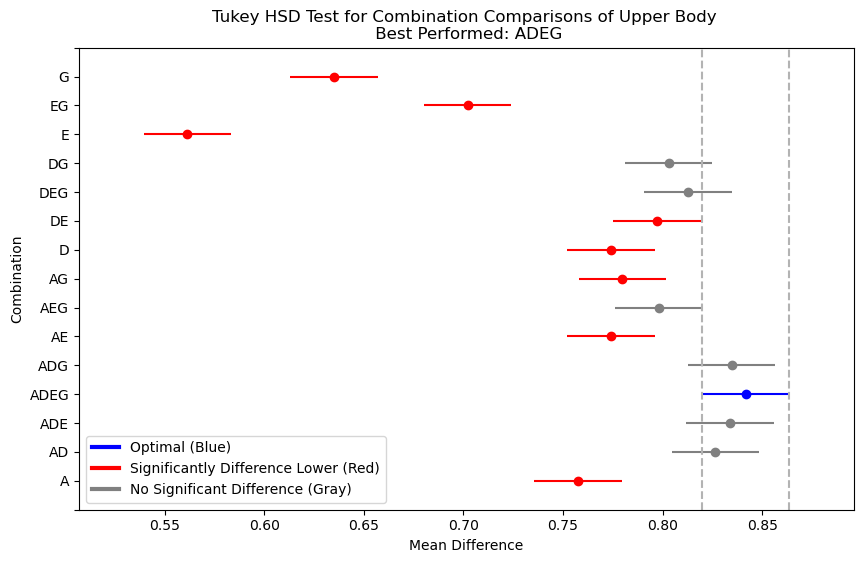

|    | placess   |   Performance_max |   Performance_min |   Performance_mean |   Performance_std |   Rank |
|---:|:----------|------------------:|------------------:|-------------------:|------------------:|-------:|
|  3 | ADEG      |          0.889216 |          0.793442 |           0.841637 |         0.0275058 |      1 |
|  4 | ADG       |          0.896294 |          0.785962 |           0.834628 |         0.0295175 |      2 |
|  2 | ADE       |          0.886957 |          0.797191 |           0.833775 |         0.0256513 |      3 |
|  1 | AD        |          0.87647  |          0.784728 |           0.826432 |         0.0283298 |      4 |
| 10 | DEG       |          0.854784 |          0.768026 |           0.812697 |         0.0263402 |      5 |
| 11 | DG        |          0.862721 |          0.777338 |           0.802997 |         0.0248354 |      6 |
|  6 | AEG       |          0.848739 |          0.757794 |           0.797917 |         0.0292967 |      7 |
|  9 | DE        | 

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import shapiro, levene
import seaborn as sns
import ast

# Load and preprocess data
data_ = pd.read_csv(r'Codes\comparison of Upper_SVM sensor position_Multi_.csv')
df_ = pd.DataFrame(data_)

df_['placess'] = df_['placess'].apply(ast.literal_eval)
df_['placess'] = df_['placess'].apply(lambda x: ''.join(x))
df_['Num_Sensors'] = df_['placess'].apply(len)
# df_['Performance'] = np.sqrt(df_['specificities'] * df_['recalls'])
df_['Performance'] = df_['f1_scores']

data = df_[df_['Num_Sensors'] >= 1]          #
# data = df_

# Check Assumptions

# # 1. Normality of Residuals
# model = sm.formula.ols('Performance ~ C(placess)', data=data).fit()
# residuals = model.resid

# # Shapiro-Wilk test for normality
# shapiro_test = shapiro(residuals)
# print(f"Shapiro-Wilk test p-value: {shapiro_test.pvalue}")

# # Q-Q plot
# sm.qqplot(residuals, line='s')
# plt.title('Q-Q Plot of Residuals')
# plt.show()

# # 2. Homogeneity of Variance
# grouped_residuals = [data.loc[data['placess'] == group, 'Performance'] for group in data['placess'].unique()]
# levene_test = levene(*grouped_residuals)
# print(f"Levene's test p-value: {levene_test.pvalue}")

# ANOVA
anova_model = sm.formula.ols('Performance ~ C(placess)', data=data).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)
print(anova_table)

# Tukey's HSD test
tukey = pairwise_tukeyhsd(endog=data['Performance'], groups=data['placess'], alpha=0.05)

# Extract results from Tukey's HSD
summary_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])
summary_df['reject'] = summary_df['reject'].astype(bool)

# Optimal combination
optimal_combination = data.groupby('placess')['Performance'].mean().idxmax()

# Plotting
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the Tukey HSD results
tukey.plot_simultaneous(ax=ax, comparison_name=optimal_combination)
# Add a legend
colors = {'Optimal (Blue)': 'blue', 'Significantly Difference Lower (Red)': 'red', 'No Significant Difference (Gray)': 'gray'}
labels = list(colors.keys())
handles = [plt.Line2D([0, 1], [0, 0], color=colors[label], linewidth=3) for label in labels]
ax.legend(handles, labels)

# Customizing the plot
plt.title(f'Tukey HSD Test for Combination Comparisons of Upper Body \n Best Performed: {optimal_combination}')
plt.xlabel('Mean Difference')
plt.ylabel('Combination')
# plt.legend()
plt.show()

# Calculate max, min, mean, and std for Performance for each index
features = ['Performance']
grouped_stats_df = df_.groupby('placess')[features].agg(['max', 'min', 'mean', 'std'])

# Flatten the multi-level column index
grouped_stats_df.columns = ['_'.join(col) for col in grouped_stats_df.columns]
grouped_stats_df = grouped_stats_df.reset_index()

# Apply ranking based on mean Performance
grouped_stats_df = grouped_stats_df.sort_values(by='Performance_mean', ascending=False)
grouped_stats_df['Rank'] = grouped_stats_df['Performance_mean'].rank(ascending=False)

print(grouped_stats_df.to_markdown())


# Identify the best combination with minimal number of sensors
best_combination = data[data['Performance'] == data['Performance'].max()]
print("\nBest Sensor Location:")
print(best_combination[['Combination', 'mean_accuracy', 'std_dev', 'placess']]) # mean_accuracy,std_dev,places

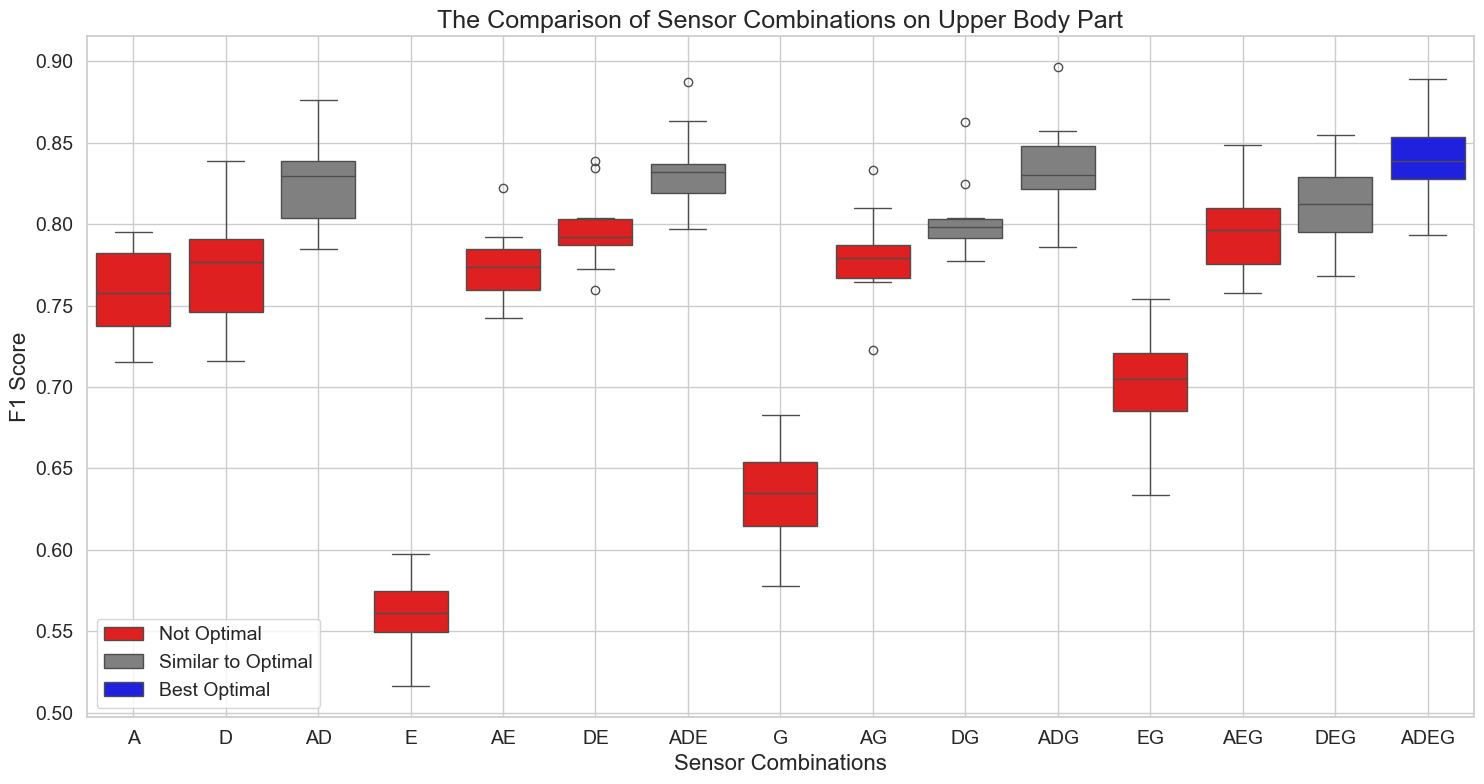

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load and preprocess data
data_ = pd.read_csv(r'Codes\comparison of Upper_SVM sensor position_Multi_.csv')
df_ = pd.DataFrame(data_)

df_['placess'] = df_['placess'].apply(ast.literal_eval)
df_['placess'] = df_['placess'].apply(lambda x: ''.join(x))
df_['Num_Sensors'] = df_['placess'].apply(len)
df_['Performance'] = df_['f1_scores']

data = df_[df_['Num_Sensors'] >= 1]

# Determine the optimal combination based on mean Performance
mean_performance = data.groupby('placess')['Performance'].mean()
best_optimal_combination = mean_performance.idxmax()
best_optimal_score = mean_performance.max()

# Define a threshold for "similar" to optimal (adjust threshold as needed)
threshold = 0.05  # You can adjust this threshold as per your need
similar_optimals = mean_performance[np.abs(mean_performance - best_optimal_score) <= threshold * best_optimal_score]

# Label combinations as Best Optimal, Similar Optimal, or Not Optimal
def categorize_combination(x):
    if x == best_optimal_combination:
        return 'Best Optimal'
    elif x in similar_optimals.index:
        return 'Similar to Optimal'
    else:
        return 'Not Optimal'

data['Category'] = data['placess'].apply(categorize_combination)



# Plotting
plt.figure(figsize=(15, 8))
# Set font sizes
plt.rcParams.update({
    'axes.titlesize': 18,     # Title size
    'axes.labelsize': 16,     # X and Y label size
    'xtick.labelsize': 14,    # X-axis tick label size
    'ytick.labelsize': 14,    # Y-axis tick label size
    'legend.fontsize': 14,    # Legend font size
    'figure.titlesize': 20    # Figure title size
})
# Boxplot with different colors for Best Optimal, Similar Optimal, and Not Optimal
sns.boxplot(x='placess', y='Performance', hue='Category', data=data, 
            palette={'Best Optimal': 'blue', 'Similar to Optimal': 'gray', 'Not Optimal': 'red'}) #'BestOptimal (Blue)': 'blue', 'Significantly Difference Lower (Red)': 'red', 'No Significant Difference (Gray)': 'gray'

# Add labels and title
plt.title('The Comparison of Sensor Combinations on Upper Body Part')
plt.xlabel('Sensor Combinations')
plt.ylabel('F1 Score')
plt.legend()

# Show the plot
plt.grid(True)
plt.tight_layout()
plt.show()


              sum_sq     df          F        PR(>F)
C(placess)  0.876008   14.0  77.477037  2.657756e-57
Residual    0.109029  135.0        NaN           NaN
Kruskal-Wallis Test p-value: 0.0000


C:\Users\sokea\AppData\Local\Temp\ipykernel_18632\1313115883.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='placess', y='Performance', data=data, ax=ax, palette='Set2')


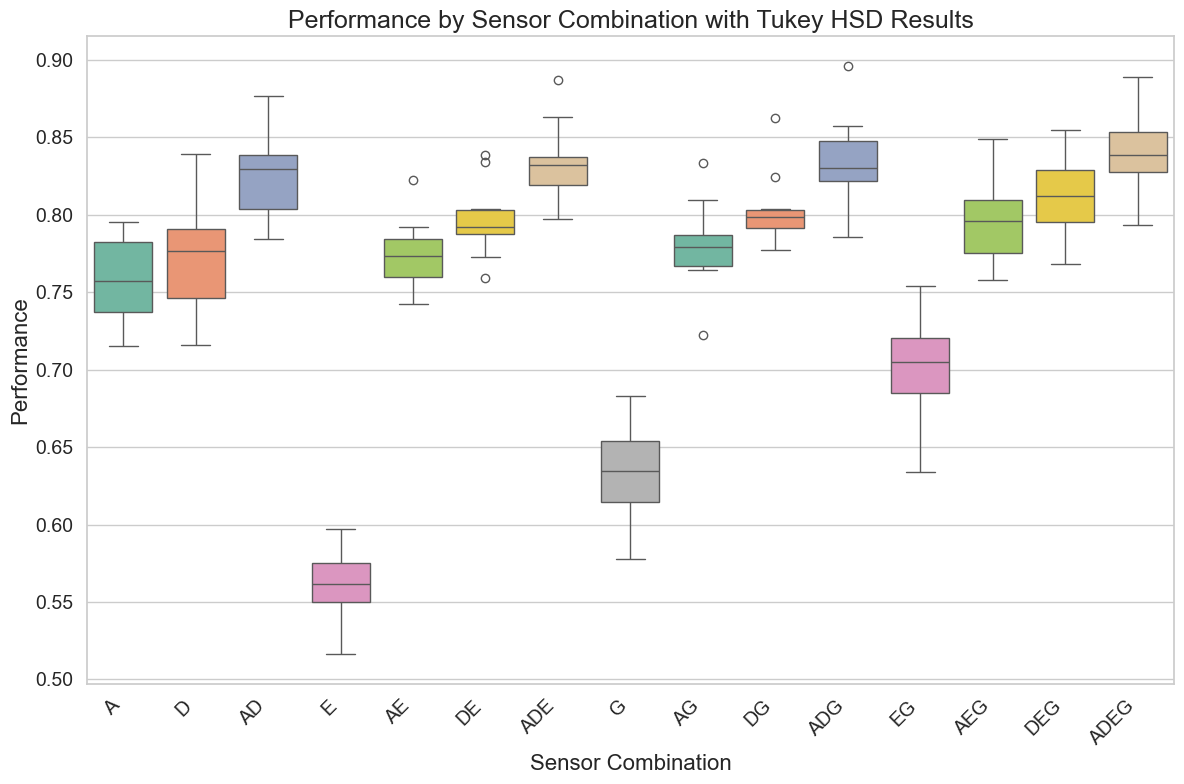

|    | placess   |   Performance_max |   Performance_min |   Performance_mean |   Performance_std |   Rank |
|---:|:----------|------------------:|------------------:|-------------------:|------------------:|-------:|
|  3 | ADEG      |          0.889216 |          0.793442 |           0.841637 |         0.0275058 |      1 |
|  4 | ADG       |          0.896294 |          0.785962 |           0.834628 |         0.0295175 |      2 |
|  2 | ADE       |          0.886957 |          0.797191 |           0.833775 |         0.0256513 |      3 |
|  1 | AD        |          0.87647  |          0.784728 |           0.826432 |         0.0283298 |      4 |
| 10 | DEG       |          0.854784 |          0.768026 |           0.812697 |         0.0263402 |      5 |
| 11 | DG        |          0.862721 |          0.777338 |           0.802997 |         0.0248354 |      6 |
|  6 | AEG       |          0.848739 |          0.757794 |           0.797917 |         0.0292967 |      7 |
|  9 | DE        | 

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import kruskal
import ast

# Load and preprocess data
data_ = pd.read_csv(r'Codes\comparison of Upper_SVM sensor position_Multi_.csv')
df_ = pd.DataFrame(data_)

df_['placess'] = df_['placess'].apply(ast.literal_eval)
df_['placess'] = df_['placess'].apply(lambda x: ''.join(x))
df_['Num_Sensors'] = df_['placess'].apply(len)
df_['Performance'] = df_['f1_scores']

data = df_[df_['Num_Sensors'] >= 1]

# ANOVA
anova_model = sm.formula.ols('Performance ~ C(placess)', data=data).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)
print(anova_table)

# Tukey's HSD test
tukey = pairwise_tukeyhsd(endog=data['Performance'], groups=data['placess'], alpha=0.05)

# Extract results from Tukey's HSD
summary_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])
summary_df['reject'] = summary_df['reject'].astype(bool)

# Optimal combination
optimal_combination = data.groupby('placess')['Performance'].mean().idxmax()

# Kruskal-Wallis Test
groups = [data.loc[data['placess'] == place, 'Performance'].values for place in data['placess'].unique()]
kruskal_stat, kruskal_p_value = kruskal(*groups)
print(f"Kruskal-Wallis Test p-value: {kruskal_p_value:.4f}")

# Set font sizes
plt.rcParams.update({
    'axes.titlesize': 18,     # Title size
    'axes.labelsize': 16,     # X and Y label size
    'xtick.labelsize': 14,    # X-axis tick label size
    'ytick.labelsize': 14,    # Y-axis tick label size
    'legend.fontsize': 14,    # Legend font size
    'figure.titlesize': 20    # Figure title size
})

# Plotting
fig, ax = plt.subplots(figsize=(12, 8))

# Create boxplot
sns.boxplot(x='placess', y='Performance', data=data, ax=ax, palette='Set2')

# Add annotations for Tukey HSD results
# for i, row in summary_df.iterrows():
#     if row['reject']:
#         # Annotate significant differences
#         plt.text(x=i, y=row['meandiff'], s='*', color='red', fontsize=16, ha='center')

# # Add Kruskal-Wallis p-value annotation
# plt.text(0.5, 0.95, f'Kruskal-Wallis p-value: {kruskal_p_value:.4f}', horizontalalignment='center', 
#          verticalalignment='center', transform=plt.gca().transAxes, fontsize=14)

# Customizing the plot
plt.title(f'Performance by Sensor Combination with Tukey HSD Results')
plt.xlabel('Sensor Combination')
plt.ylabel('Performance')
plt.xticks(rotation=45, ha='right')

# Add a legend (if necessary)
# plt.legend(title="Legend Title")

plt.tight_layout()
plt.show()

# Calculate max, min, mean, and std for Performance for each index
features = ['Performance']
grouped_stats_df = df_.groupby('placess')[features].agg(['max', 'min', 'mean', 'std'])

# Flatten the multi-level column index
grouped_stats_df.columns = ['_'.join(col) for col in grouped_stats_df.columns]
grouped_stats_df = grouped_stats_df.reset_index()

# Apply ranking based on mean Performance
grouped_stats_df = grouped_stats_df.sort_values(by='Performance_mean', ascending=False)
grouped_stats_df['Rank'] = grouped_stats_df['Performance_mean'].rank(ascending=False)

print(grouped_stats_df.to_markdown())

# Identify the best combination with minimal number of sensors
best_combination = data[data['Performance'] == data['Performance'].max()]
print("\nBest Sensor Location:")
print(best_combination[['placess', 'Performance']])


Shapiro-Wilk test p-value: 0.12011758357169977


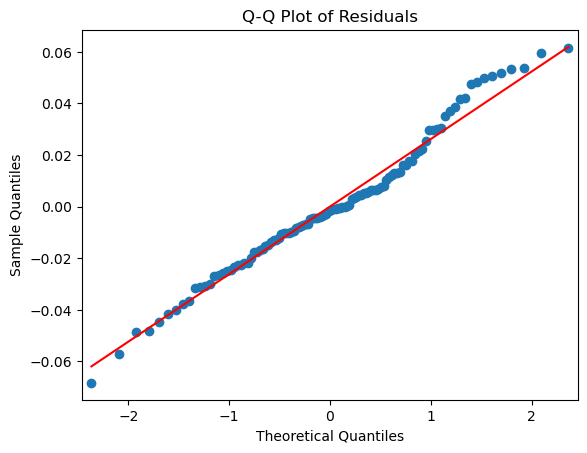

Levene's test p-value: 0.9951392818165797
              sum_sq    df          F        PR(>F)
C(placess)  0.156305  10.0  20.529511  4.756775e-20
Residual    0.075376  99.0        NaN           NaN


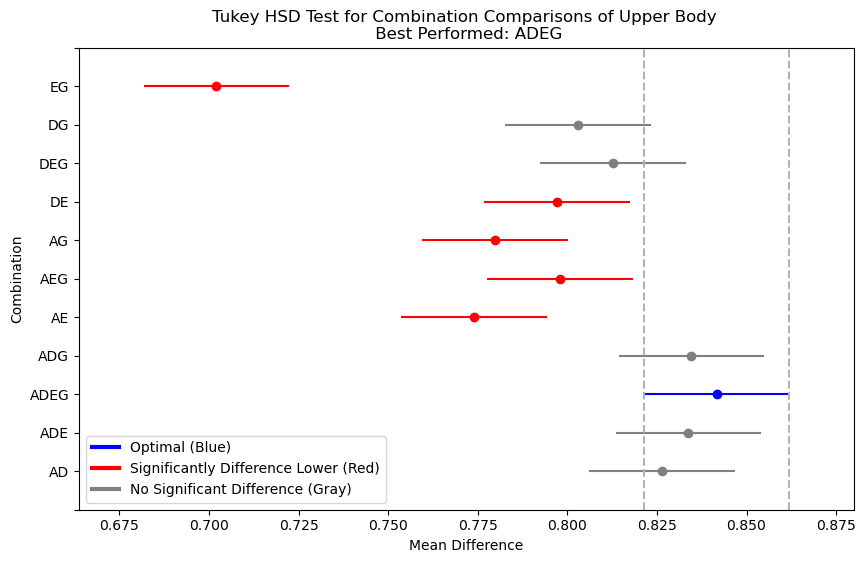

|    | placess   |   Performance_max |   Performance_min |   Performance_mean |   Performance_std |   Rank |
|---:|:----------|------------------:|------------------:|-------------------:|------------------:|-------:|
|  3 | ADEG      |          0.889216 |          0.793442 |           0.841637 |         0.0275058 |      1 |
|  4 | ADG       |          0.896294 |          0.785962 |           0.834628 |         0.0295175 |      2 |
|  2 | ADE       |          0.886957 |          0.797191 |           0.833775 |         0.0256513 |      3 |
|  1 | AD        |          0.87647  |          0.784728 |           0.826432 |         0.0283298 |      4 |
| 10 | DEG       |          0.854784 |          0.768026 |           0.812697 |         0.0263402 |      5 |
| 11 | DG        |          0.862721 |          0.777338 |           0.802997 |         0.0248354 |      6 |
|  6 | AEG       |          0.848739 |          0.757794 |           0.797917 |         0.0292967 |      7 |
|  9 | DE        | 

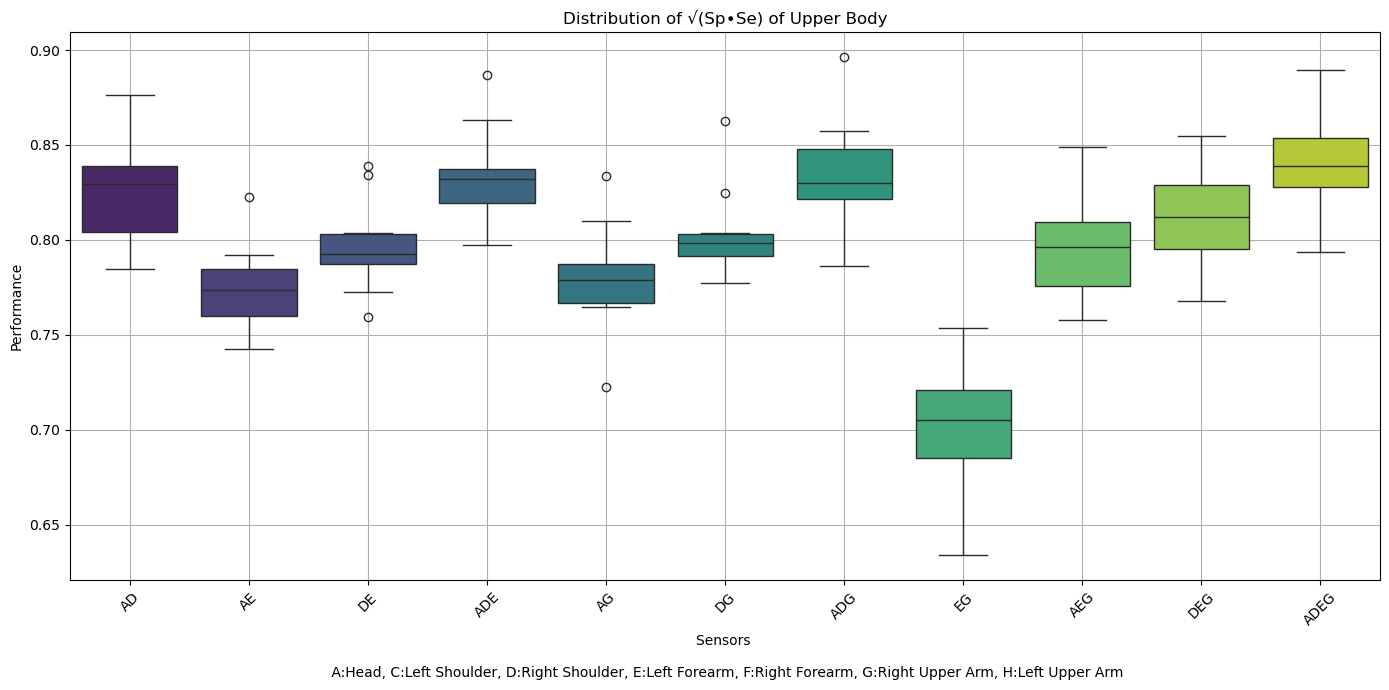


Best Sensor Location:
     Combination  mean_accuracy  std_dev placess
107           10       0.837333  0.02795     ADG


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import shapiro, levene
import seaborn as sns
import ast

# Load and preprocess data
data_ = pd.read_csv(r'Codes\comparison of Upper_SVM sensor position_Multi_.csv')
df_ = pd.DataFrame(data_)

df_['placess'] = df_['placess'].apply(ast.literal_eval)
df_['placess'] = df_['placess'].apply(lambda x: ''.join(x))
df_['Num_Sensors'] = df_['placess'].apply(len)
# df_['Performance'] = np.sqrt(df_['specificities'] * df_['recalls'])
df_['Performance'] = df_['f1_scores']

data = df_[df_['Num_Sensors'] >= 2]          #
# data = df_

# Check Assumptions

# 1. Normality of Residuals
model = sm.formula.ols('Performance ~ C(placess)', data=data).fit()
residuals = model.resid

# Shapiro-Wilk test for normality
shapiro_test = shapiro(residuals)
print(f"Shapiro-Wilk test p-value: {shapiro_test.pvalue}")

# Q-Q plot
sm.qqplot(residuals, line='s')
plt.title('Q-Q Plot of Residuals')
plt.show()

# 2. Homogeneity of Variance
grouped_residuals = [data.loc[data['placess'] == group, 'Performance'] for group in data['placess'].unique()]
levene_test = levene(*grouped_residuals)
print(f"Levene's test p-value: {levene_test.pvalue}")

# ANOVA
anova_model = sm.formula.ols('Performance ~ C(placess)', data=data).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)
print(anova_table)

# Tukey's HSD test
tukey = pairwise_tukeyhsd(endog=data['Performance'], groups=data['placess'], alpha=0.05)

# Extract results from Tukey's HSD
summary_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])
summary_df['reject'] = summary_df['reject'].astype(bool)

# Optimal combination
optimal_combination = data.groupby('placess')['Performance'].mean().idxmax()

# Plotting
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the Tukey HSD results
tukey.plot_simultaneous(ax=ax, comparison_name=optimal_combination)

# Highlighting the optimal combination
# ax.axhline(optimal_combination, color='blue', linestyle='--', label='Optimal Combination')
# y_labels = ax.get_yticklabels()
# for label in y_labels:
#     text = label.get_text()
#     if text in optimal_combination:
#         label.set_color('blue')
        
# Customizing the plot
plt.title(f'Tukey HSD Test for Combination Comparisons of Upper Body \n Best Performed: {optimal_combination}')
plt.xlabel('Mean Difference')
plt.ylabel('Combination')
# Add a legend
colors = {'Optimal (Blue)': 'blue', 'Significantly Difference Lower (Red)': 'red', 'No Significant Difference (Gray)': 'gray'}
labels = list(colors.keys())
handles = [plt.Line2D([0, 1], [0, 0], color=colors[label], linewidth=3) for label in labels]
ax.legend(handles, labels)

plt.show()

# Calculate max, min, mean, and std for Performance for each index
features = ['Performance']
grouped_stats_df = df_.groupby('placess')[features].agg(['max', 'min', 'mean', 'std'])

# Flatten the multi-level column index
grouped_stats_df.columns = ['_'.join(col) for col in grouped_stats_df.columns]
grouped_stats_df = grouped_stats_df.reset_index()

# Apply ranking based on mean Performance
grouped_stats_df = grouped_stats_df.sort_values(by='Performance_mean', ascending=False)
grouped_stats_df['Rank'] = grouped_stats_df['Performance_mean'].rank(ascending=False)

print(grouped_stats_df.to_markdown())

# Boxplot to visualize the distribution of accuracies by sensor combinations
plt.figure(figsize=(14, 7))
sns.boxplot(x='placess', y='Performance', data=data, palette='viridis', hue='placess', legend=False)
plt.xticks(rotation=45)
plt.title('Distribution of √(Sp∙Se) of Upper Body')
plt.xlabel('Sensors \n\n A:Head, C:Left Shoulder, D:Right Shoulder, E:Left Forearm, F:Right Forearm, G:Right Upper Arm, H:Left Upper Arm')
plt.ylabel('Performance')
plt.grid(True)
plt.tight_layout()
plt.show()

# Identify the best combination with minimal number of sensors
best_combination = data[data['Performance'] == data['Performance'].max()]
print("\nBest Sensor Location:")
print(best_combination[['Combination', 'mean_accuracy', 'std_dev', 'placess']]) # mean_accuracy,std_dev,places

Shapiro-Wilk test p-value: 0.04789355495322695


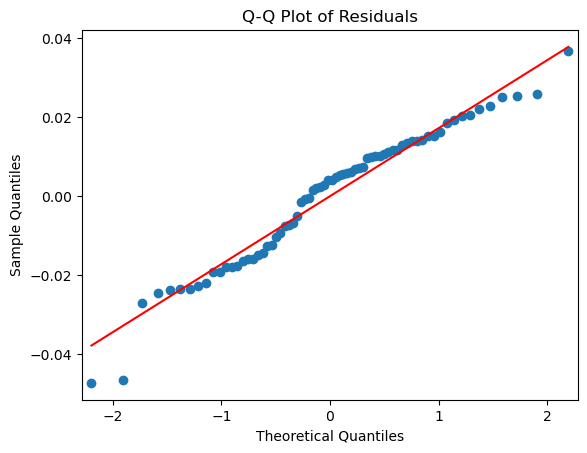

Levene's test p-value: 0.43615527907754736
              sum_sq    df          F        PR(>F)
C(placess)  0.104668   6.0  52.869049  9.821663e-23
Residual    0.020788  63.0        NaN           NaN


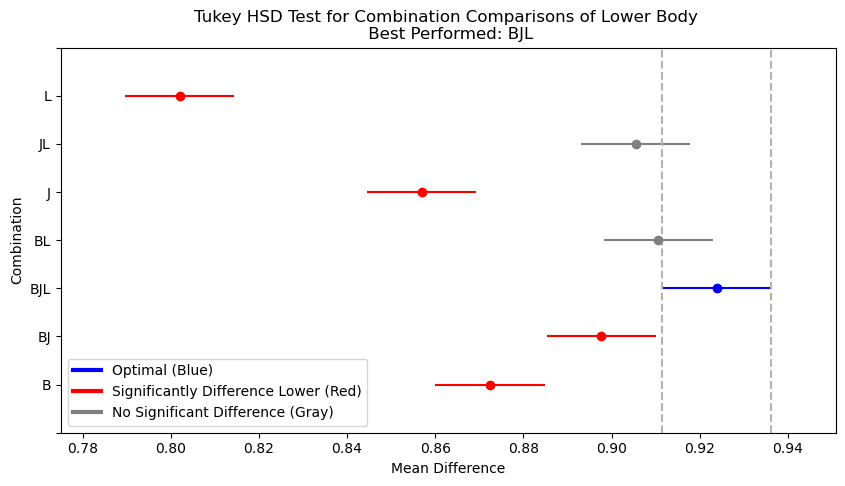

|    | placess   |   Performance_max |   Performance_min |   Performance_mean |   Performance_std |   Rank |
|---:|:----------|------------------:|------------------:|-------------------:|------------------:|-------:|
|  2 | BJL       |          0.944038 |          0.901014 |           0.923771 |         0.013779  |      1 |
|  3 | BL        |          0.936358 |          0.892646 |           0.910569 |         0.0163708 |      2 |
|  5 | JL        |          0.919662 |          0.882105 |           0.905491 |         0.0135746 |      3 |
|  1 | BJ        |          0.923148 |          0.873774 |           0.897646 |         0.0165    |      4 |
|  0 | B         |          0.894535 |          0.853092 |           0.872415 |         0.0138325 |      5 |
|  4 | J         |          0.879791 |          0.810296 |           0.856895 |         0.0236601 |      6 |
|  6 | L         |          0.838832 |          0.754759 |           0.802057 |         0.0253813 |      7 |


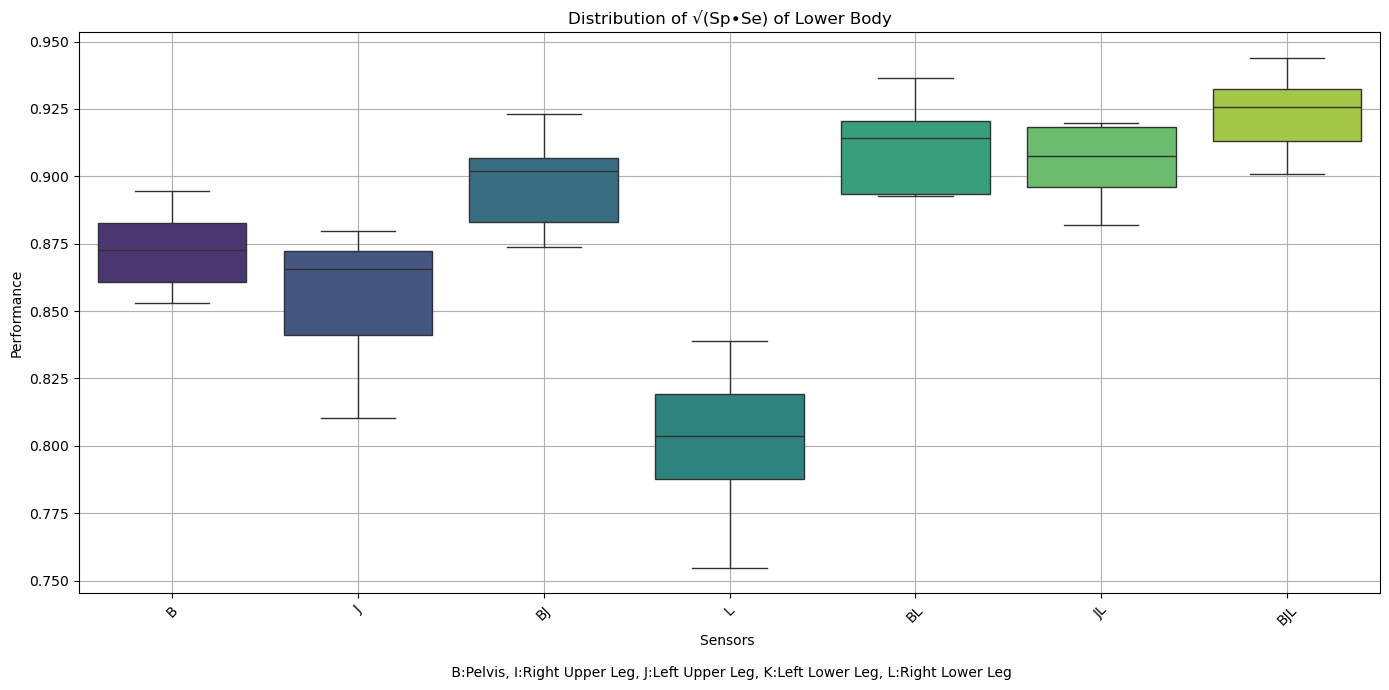


Best Sensor Location:
    Combination  mean_accuracy   std_dev placess
60            6        0.92441  0.012884     BJL


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import shapiro, levene
import ast

# Load and preprocess data
data_ = pd.read_csv(r'Codes\comparison of Lower_SVM sensor position_Multi_.csv')
df_ = pd.DataFrame(data_)

df_['placess'] = df_['placess'].apply(ast.literal_eval)
df_['placess'] = df_['placess'].apply(lambda x: ''.join(x))
df_['Num_Sensors'] = df_['placess'].apply(len)
# df_['Performance'] = np.sqrt(df_['specificities'] * df_['recalls'])
df_['Performance'] = df_['f1_scores']

data = df_[df_['Num_Sensors'] >= 1]          #
# data = df_

# Check Assumptions

# 1. Normality of Residuals
model = sm.formula.ols('Performance ~ C(placess)', data=data).fit()
residuals = model.resid

# Shapiro-Wilk test for normality
shapiro_test = shapiro(residuals)
print(f"Shapiro-Wilk test p-value: {shapiro_test.pvalue}")

# Q-Q plot
sm.qqplot(residuals, line='s')
plt.title('Q-Q Plot of Residuals')
plt.show()

# 2. Homogeneity of Variance
grouped_residuals = [data.loc[data['placess'] == group, 'Performance'] for group in data['placess'].unique()]
levene_test = levene(*grouped_residuals)
print(f"Levene's test p-value: {levene_test.pvalue}")

# ANOVA
anova_model = sm.formula.ols('Performance ~ C(placess)', data=data).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)
print(anova_table)

# Tukey's HSD test
tukey = pairwise_tukeyhsd(endog=data['Performance'], groups=data['placess'], alpha=0.05)

# Extract results from Tukey's HSD
summary_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])
summary_df['reject'] = summary_df['reject'].astype(bool)

# Optimal combination
optimal_combination = data.groupby('placess')['Performance'].mean().idxmax()

# Plotting
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the Tukey HSD results
tukey.plot_simultaneous(ax=ax, figsize=(10, 5), comparison_name=optimal_combination)

# Highlighting the optimal combination
# ax.axvline(optimal_combination_stats['mean'], color='blue', linestyle='--', label=f'Best Performed: {optimal_combination_name}')

# Customizing the plot
plt.title(f'Tukey HSD Test for Combination Comparisons of Lower Body \n Best Performed: {optimal_combination}')
plt.xlabel('Mean Difference')
plt.ylabel('Combination')
# Add a legend
colors = {'Optimal (Blue)': 'blue', 'Significantly Difference Lower (Red)': 'red', 'No Significant Difference (Gray)': 'gray'}
labels = list(colors.keys())
handles = [plt.Line2D([0, 1], [0, 0], color=colors[label], linewidth=3) for label in labels]
ax.legend(handles, labels)

plt.show()

# Calculate max, min, mean, and std for Performance for each index
features = ['Performance']
grouped_stats_df = df_.groupby('placess')[features].agg(['max', 'min', 'mean', 'std'])

# Flatten the multi-level column index
grouped_stats_df.columns = ['_'.join(col) for col in grouped_stats_df.columns]
grouped_stats_df = grouped_stats_df.reset_index()

# Apply ranking based on mean Performance
grouped_stats_df = grouped_stats_df.sort_values(by='Performance_mean', ascending=False)
grouped_stats_df['Rank'] = grouped_stats_df['Performance_mean'].rank(ascending=False)

print(grouped_stats_df.to_markdown())

# Boxplot to visualize the distribution of accuracies by sensor combinations
plt.figure(figsize=(14, 7))
sns.boxplot(x='placess', y='Performance', data=data, palette='viridis', hue='placess', legend=False)
plt.xticks(rotation=45)
plt.title('Distribution of √(Sp∙Se) of Lower Body')
plt.xlabel('Sensors \n\n B:Pelvis, I:Right Upper Leg, J:Left Upper Leg, K:Left Lower Leg, L:Right Lower Leg')
plt.ylabel('Performance')
plt.grid(True)
plt.tight_layout()
plt.show()

# Identify the best combination with minimal number of sensors
best_combination = data[data['Performance'] == data['Performance'].max()]
print("\nBest Sensor Location:")
print(best_combination[['Combination', 'mean_accuracy', 'std_dev', 'placess']]) # mean_accuracy,std_dev,places

              sum_sq    df          F        PR(>F)
C(placess)  0.104668   6.0  52.869049  9.821663e-23
Residual    0.020788  63.0        NaN           NaN
Kruskal-Wallis Test p-value: 0.0000


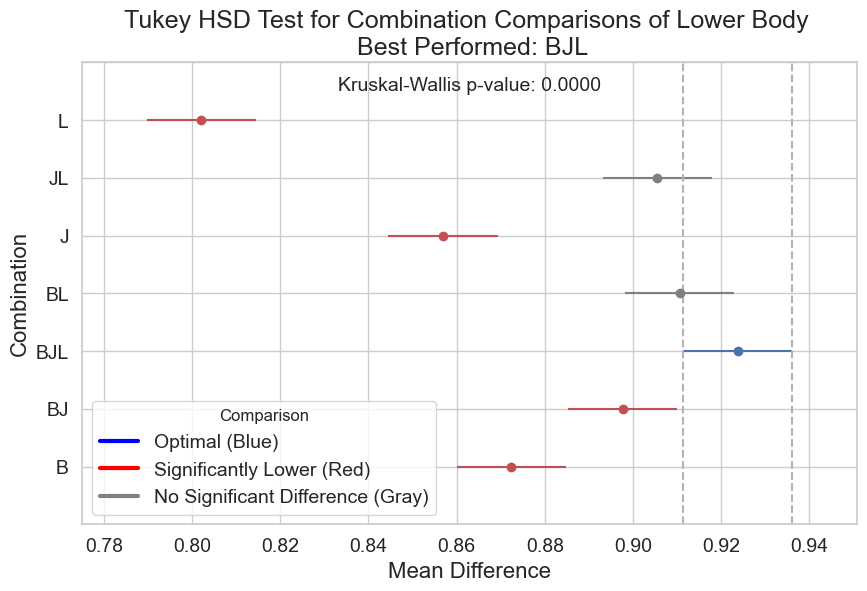

|    | placess   |   Performance_max |   Performance_min |   Performance_mean |   Performance_std |   Rank |
|---:|:----------|------------------:|------------------:|-------------------:|------------------:|-------:|
|  2 | BJL       |          0.944038 |          0.901014 |           0.923771 |         0.013779  |      1 |
|  3 | BL        |          0.936358 |          0.892646 |           0.910569 |         0.0163708 |      2 |
|  5 | JL        |          0.919662 |          0.882105 |           0.905491 |         0.0135746 |      3 |
|  1 | BJ        |          0.923148 |          0.873774 |           0.897646 |         0.0165    |      4 |
|  0 | B         |          0.894535 |          0.853092 |           0.872415 |         0.0138325 |      5 |
|  4 | J         |          0.879791 |          0.810296 |           0.856895 |         0.0236601 |      6 |
|  6 | L         |          0.838832 |          0.754759 |           0.802057 |         0.0253813 |      7 |

Best Sensor Locati

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import kruskal
import ast

# Load and preprocess data
data_ = pd.read_csv(r'Codes\comparison of Lower_SVM sensor position_Multi_.csv')
df_ = pd.DataFrame(data_)

df_['placess'] = df_['placess'].apply(ast.literal_eval)
df_['placess'] = df_['placess'].apply(lambda x: ''.join(x))
df_['Num_Sensors'] = df_['placess'].apply(len)
df_['Performance'] = df_['f1_scores']

data = df_[df_['Num_Sensors'] >= 1]

# ANOVA
anova_model = sm.formula.ols('Performance ~ C(placess)', data=data).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)
print(anova_table)

# Tukey's HSD test
tukey = pairwise_tukeyhsd(endog=data['Performance'], groups=data['placess'], alpha=0.05)

# Extract results from Tukey's HSD
summary_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])
summary_df['reject'] = summary_df['reject'].astype(bool)

# Optimal combination
optimal_combination = data.groupby('placess')['Performance'].mean().idxmax()

# Kruskal-Wallis Test
groups = [data.loc[data['placess'] == place, 'Performance'].values for place in data['placess'].unique()]
kruskal_stat, kruskal_p_value = kruskal(*groups)
print(f"Kruskal-Wallis Test p-value: {kruskal_p_value:.4f}")

# Set font sizes
plt.rcParams.update({
    'axes.titlesize': 18,     # Title size
    'axes.labelsize': 16,     # X and Y label size
    'xtick.labelsize': 14,    # X-axis tick label size
    'ytick.labelsize': 14,    # Y-axis tick label size
    'legend.fontsize': 14,    # Legend font size
    'figure.titlesize': 20    # Figure title size
})

# Plotting
fig, ax = plt.subplots(figsize=(12, 8))

# Plot Tukey HSD results
tukey.plot_simultaneous(ax=ax, comparison_name=optimal_combination)

# Add Kruskal-Wallis p-value annotation
plt.text(0.5, 0.95, f'Kruskal-Wallis p-value: {kruskal_p_value:.4f}', horizontalalignment='center', 
         verticalalignment='center', transform=plt.gca().transAxes, fontsize=14)

# Customizing the plot
plt.title(f'Tukey HSD Test for Combination Comparisons of Lower Body \n Best Performed: {optimal_combination}')
plt.xlabel('Mean Difference')
plt.ylabel('Combination')
# Add a legend
colors = {'Optimal (Blue)': 'blue', 'Significantly Lower (Red)': 'red', 'No Significant Difference (Gray)': 'gray'}
labels = list(colors.keys())
handles = [plt.Line2D([0, 1], [0, 0], color=colors[label], linewidth=3) for label in labels]
ax.legend(handles, labels, title="Comparison")

plt.show()

# Calculate max, min, mean, and std for Performance for each index
features = ['Performance']
grouped_stats_df = df_.groupby('placess')[features].agg(['max', 'min', 'mean', 'std'])

# Flatten the multi-level column index
grouped_stats_df.columns = ['_'.join(col) for col in grouped_stats_df.columns]
grouped_stats_df = grouped_stats_df.reset_index()

# Apply ranking based on mean Performance
grouped_stats_df = grouped_stats_df.sort_values(by='Performance_mean', ascending=False)
grouped_stats_df['Rank'] = grouped_stats_df['Performance_mean'].rank(ascending=False)

print(grouped_stats_df.to_markdown())

# Identify the best combination with minimal number of sensors
best_combination = data[data['Performance'] == data['Performance'].max()]
print("\nBest Sensor Location:")
print(best_combination[['Combination', 'mean_accuracy', 'std_dev', 'placess']])


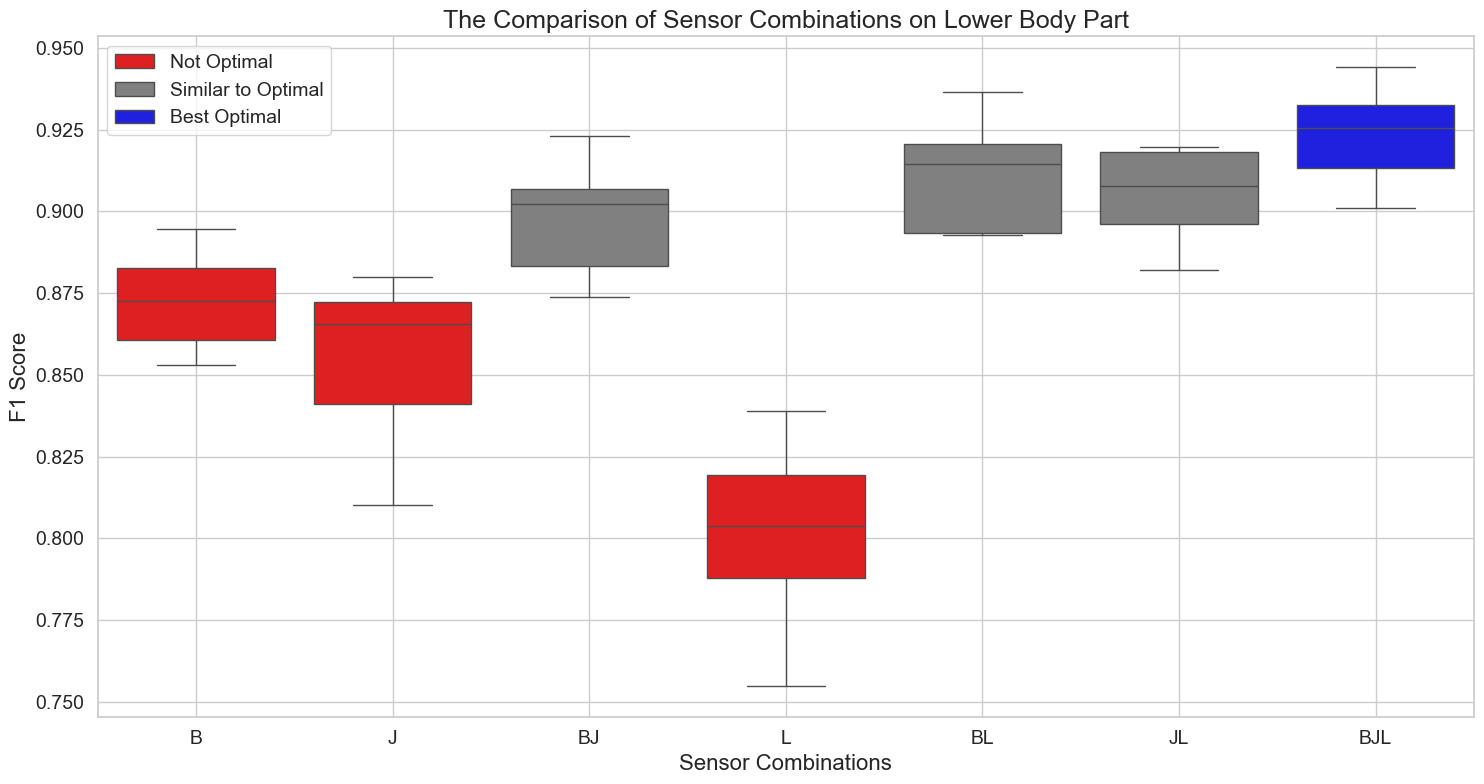

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load and preprocess data
data_ = pd.read_csv(r'Codes\comparison of Lower_SVM sensor position_Multi_.csv')
df_ = pd.DataFrame(data_)

df_['placess'] = df_['placess'].apply(ast.literal_eval)
df_['placess'] = df_['placess'].apply(lambda x: ''.join(x))
df_['Num_Sensors'] = df_['placess'].apply(len)
df_['Performance'] = df_['f1_scores']

data = df_[df_['Num_Sensors'] >= 1]

# Determine the optimal combination based on mean Performance
mean_performance = data.groupby('placess')['Performance'].mean()
best_optimal_combination = mean_performance.idxmax()
best_optimal_score = mean_performance.max()

# Define a threshold for "similar" to optimal (adjust threshold as needed)
threshold = 0.05  # You can adjust this threshold as per your need
similar_optimals = mean_performance[np.abs(mean_performance - best_optimal_score) <= threshold * best_optimal_score]

# Label combinations as Best Optimal, Similar Optimal, or Not Optimal
def categorize_combination(x):
    if x == best_optimal_combination:
        return 'Best Optimal'
    elif x in similar_optimals.index:
        return 'Similar to Optimal'
    else:
        return 'Not Optimal'

data['Category'] = data['placess'].apply(categorize_combination)



# Plotting
plt.figure(figsize=(15, 8))
# Set font sizes
plt.rcParams.update({
    'axes.titlesize': 18,     # Title size
    'axes.labelsize': 16,     # X and Y label size
    'xtick.labelsize': 14,    # X-axis tick label size
    'ytick.labelsize': 14,    # Y-axis tick label size
    'legend.fontsize': 14,    # Legend font size
    'figure.titlesize': 20    # Figure title size
})
# Boxplot with different colors for Best Optimal, Similar Optimal, and Not Optimal
sns.boxplot(x='placess', y='Performance', hue='Category', data=data, 
            palette={'Best Optimal': 'blue', 'Similar to Optimal': 'gray', 'Not Optimal': 'red'}) #'BestOptimal (Blue)': 'blue', 'Significantly Difference Lower (Red)': 'red', 'No Significant Difference (Gray)': 'gray'

# Add labels and title
plt.title('The Comparison of Sensor Combinations on Lower Body Part')
plt.xlabel('Sensor Combinations')
plt.ylabel('F1 Score')
plt.legend()

# Show the plot
plt.grid(True)
plt.tight_layout()
plt.show()
